In [7]:
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = "cleaned_output/Fitbit_ba_cleaned"

sleep_df = pd.read_excel(f"{BASE_DIR}/Fitbit_ba_sleep_score_cleaned.xlsx")
stress_df = pd.read_excel(f"{BASE_DIR}/Fitbit_ba_stress_score_cleaned.xlsx")
activity_df = pd.read_excel(f"{BASE_DIR}/Fitbit_ba_active_zone_minutes_(azm)_cleaned.xlsx")


In [8]:
sleep_df.columns, stress_df.columns, activity_df.columns


(Index(['sleep_log_entry_id', 'timestamp', 'overall_score', 'composition_score',
        'revitalization_score', 'duration_score', 'deep_sleep_in_minutes',
        'resting_heart_rate', 'restlessness', 'source_file'],
       dtype='object'),
 Index(['date', 'updated_at', 'stress_score', 'sleep_points',
        'max_sleep_points', 'responsiveness_points',
        'max_responsiveness_points', 'exertion_points', 'max_exertion_points',
        'status', 'calculation_failed', 'source_file'],
       dtype='object'),
 Index(['date_time', 'heart_zone_id', 'total_minutes', 'source_file'], dtype='object'))

In [9]:
sleep_df["date"] = pd.to_datetime(
    sleep_df["timestamp"], errors="coerce"
).dt.date

sleep_daily = (
    sleep_df
    .groupby("date")["overall_score"]
    .mean()
    .reset_index(name="sleep_score")
)

sleep_daily


,date,sleep_score
0,2025-08-02,68.0
1,2025-08-03,78.0
2,2025-08-04,69.0
3,2025-08-05,69.0
4,2025-08-06,58.0
5,2025-08-07,66.0


In [10]:
stress_df["date"] = pd.to_datetime(stress_df["date"], errors="coerce").dt.date

stress_daily = stress_df[["date", "stress_score"]]

stress_daily


,date,stress_score
0,2025-08-01,0
1,2025-08-02,70
2,2025-08-03,74
3,2025-08-04,69
4,2025-08-05,65
5,2025-08-06,66
6,2025-08-07,73


In [11]:
activity_df["date"] = pd.to_datetime(
    activity_df["date_time"], errors="coerce"
).dt.date

activity_daily = (
    activity_df
    .groupby("date")["total_minutes"]
    .sum()
    .reset_index(name="active_minutes")
)

activity_daily


,date,active_minutes
0,2025-08-01,15
1,2025-08-02,1
2,2025-08-03,1
3,2025-08-04,2
4,2025-08-05,1
5,2025-08-06,8
6,2025-08-07,1


In [12]:
daily_ba = sleep_daily.merge(stress_daily, on="date", how="left")
daily_ba = daily_ba.merge(activity_daily, on="date", how="left")

daily_ba


,date,sleep_score,stress_score,active_minutes
0,2025-08-02,68.0,70,1
1,2025-08-03,78.0,74,1
2,2025-08-04,69.0,69,2
3,2025-08-05,69.0,65,1
4,2025-08-06,58.0,66,8
5,2025-08-07,66.0,73,1


In [13]:
daily_ba.describe()


,sleep_score,stress_score,active_minutes
count,6.000000,6.000000,6.000000
mean,68.000000,69.500000,2.333333
std,6.418723,3.619392,2.804758
min,58.000000,65.000000,1.000000
25%,66.500000,66.750000,1.000000
50%,68.500000,69.500000,1.000000
75%,69.000000,72.250000,1.750000
max,78.000000,74.000000,8.000000


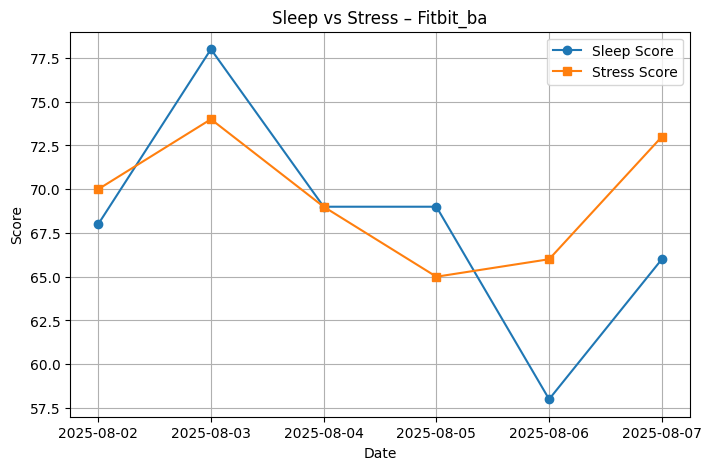

In [14]:
plt.figure(figsize=(8,5))
plt.plot(daily_ba["date"], daily_ba["sleep_score"], marker="o", label="Sleep Score")
plt.plot(daily_ba["date"], daily_ba["stress_score"], marker="s", label="Stress Score")

plt.title("Sleep vs Stress – Fitbit_ba")
plt.xlabel("Date")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()


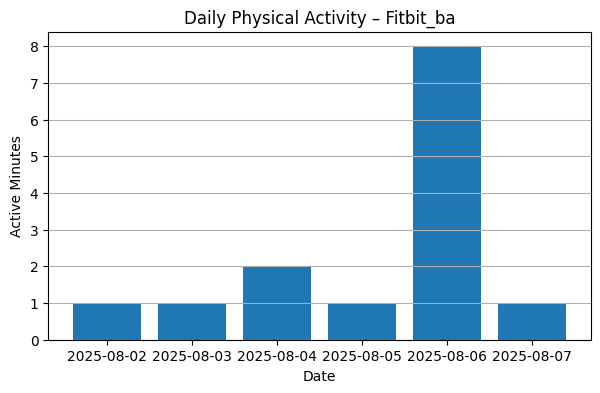

In [15]:
plt.figure(figsize=(7,4))
plt.bar(daily_ba["date"], daily_ba["active_minutes"])
plt.title("Daily Physical Activity – Fitbit_ba")
plt.xlabel("Date")
plt.ylabel("Active Minutes")
plt.grid(axis="y")
plt.show()


In [16]:
daily_ba[["sleep_score", "stress_score", "active_minutes"]].corr()


,sleep_score,stress_score,active_minutes
sleep_score,1.000000,0.585403,-0.766540
stress_score,0.585403,1.000000,-0.492537
active_minutes,-0.766540,-0.492537,1.000000


(HRV & Temperature)

In [17]:
import pandas as pd
import matplotlib.pyplot as plt


In [22]:
sleep_df = pd.read_excel(
    "cleaned_output/Fitbit_ba_cleaned/Fitbit_ba_sleep_score_cleaned.xlsx"
)

sleep_df["date"] = pd.to_datetime(
    sleep_df["timestamp"], errors="coerce"
).dt.date


In [23]:
stress_df = pd.read_excel(
    "cleaned_output/Fitbit_ba_cleaned/Fitbit_ba_stress_score_cleaned.xlsx"
)

stress_df["date"] = pd.to_datetime(
    stress_df["date"], errors="coerce"
).dt.date


In [24]:
activity_df = pd.read_excel(
    "cleaned_output/Fitbit_ba_cleaned/Fitbit_ba_active_zone_minutes_(azm)_cleaned.xlsx"
)

activity_df["date"] = pd.to_datetime(
    activity_df["date_time"], errors="coerce"
).dt.date


In [25]:
sleep_daily = (
    sleep_df
    .dropna(subset=["date", "overall_score"])
    .groupby("date")["overall_score"]
    .mean()
    .reset_index(name="sleep_score")
)


In [26]:
stress_daily = (
    stress_df
    .dropna(subset=["date", "stress_score"])
    .groupby("date")["stress_score"]
    .mean()
    .reset_index()
)


In [27]:
activity_daily = (
    activity_df
    .dropna(subset=["date", "total_minutes"])
    .groupby("date")["total_minutes"]
    .sum()
    .reset_index(name="active_minutes")
)


In [28]:
daily_df = (
    sleep_daily
    .merge(stress_daily, on="date", how="outer")
    .merge(activity_daily, on="date", how="outer")
    .sort_values("date")
)

daily_df


,date,sleep_score,stress_score,active_minutes
0,2025-08-01,NaN,0.0,15
1,2025-08-02,68.0,70.0,1
2,2025-08-03,78.0,74.0,1
3,2025-08-04,69.0,69.0,2
4,2025-08-05,69.0,65.0,1
5,2025-08-06,58.0,66.0,8
6,2025-08-07,66.0,73.0,1


In [29]:
daily_df.columns


Index(['date', 'sleep_score', 'stress_score', 'active_minutes'], dtype='object')

In [30]:
daily_df = (
    daily_df
    .merge(hrv_daily, on="date", how="left")
    .merge(temp_daily, on="date", how="left")
)


In [31]:
hrv_df = pd.read_excel(
    "cleaned_output/Fitbit_ba_cleaned/Fitbit_ba_heart_rate_variability_cleaned.xlsx"
)

hrv_df["date"] = pd.to_datetime(
    hrv_df["timestamp"], errors="coerce"
).dt.date

hrv_daily = (
    hrv_df
    .dropna(subset=["date", "rmssd"])
    .groupby("date")["rmssd"]
    .mean()
    .reset_index(name="hrv_rmssd")
)

hrv_daily.head()


,date,hrv_rmssd
0,2025-08-01,18.441300
1,2025-08-02,15.997188
2,2025-08-03,24.219250
3,2025-08-04,25.671437
4,2025-08-05,22.362493


In [32]:
hrv_stress = pd.merge(
    hrv_daily,
    stress_daily,
    on="date",
    how="inner"
)

hrv_stress


,date,hrv_rmssd,stress_score
0,2025-08-01,18.441300,0.0
1,2025-08-02,15.997188,70.0
2,2025-08-03,24.219250,74.0
3,2025-08-04,25.671437,69.0
4,2025-08-05,22.362493,65.0
5,2025-08-06,27.801744,66.0
6,2025-08-07,32.729917,73.0


In [33]:
hrv_stress[["hrv_rmssd", "stress_score"]].corr()


,hrv_rmssd,stress_score
hrv_rmssd,1.000000,0.445557
stress_score,0.445557,1.000000


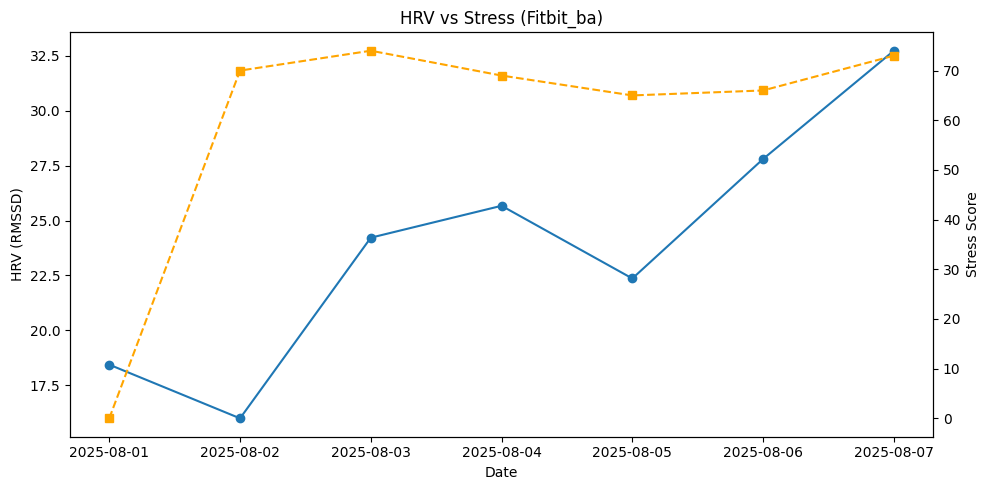

In [34]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(
    hrv_stress["date"],
    hrv_stress["hrv_rmssd"],
    marker="o",
    label="HRV (RMSSD)"
)
ax1.set_ylabel("HRV (RMSSD)")
ax1.set_xlabel("Date")

ax2 = ax1.twinx()
ax2.plot(
    hrv_stress["date"],
    hrv_stress["stress_score"],
    marker="s",
    linestyle="--",
    color="orange",
    label="Stress Score"
)
ax2.set_ylabel("Stress Score")

plt.title("HRV vs Stress (Fitbit_ba)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [35]:
temp_df = pd.read_excel(
    "cleaned_output/Fitbit_ba_cleaned/Fitbit_ba_temperature_cleaned.xlsx"
)

# Use sleep_start (Fitbit temperature is sleep-linked)
temp_df["date"] = pd.to_datetime(
    temp_df["sleep_start"], errors="coerce"
).dt.date

temp_daily = (
    temp_df
    .dropna(subset=["date", "temperature"])
    .groupby("date")["temperature"]
    .mean()
    .reset_index(name="nightly_temp")
)


In [37]:
temp_sleep = pd.merge(
    temp_daily,
    sleep_daily,
    on="date",
    how="inner"
)


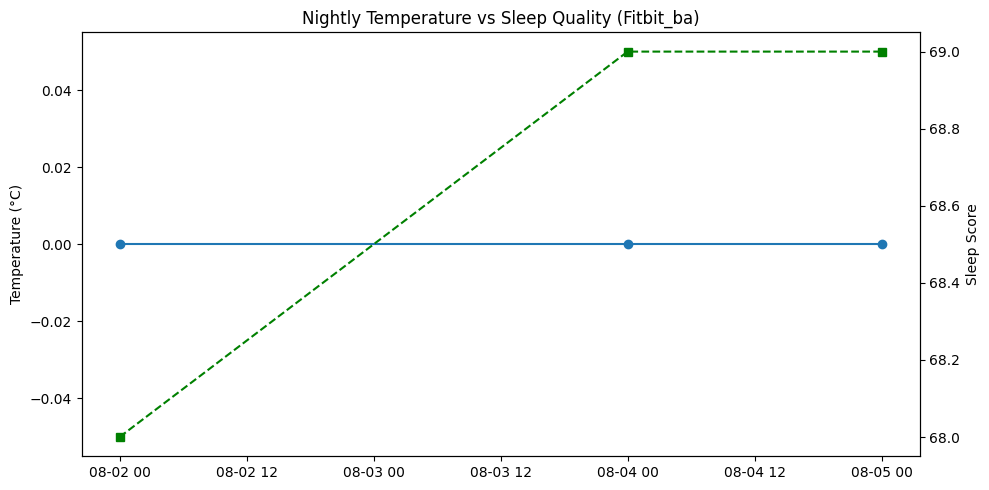

In [38]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(
    temp_sleep["date"],
    temp_sleep["nightly_temp"],
    marker="o",
    label="Nightly Temperature"
)
ax1.set_ylabel("Temperature (°C)")

ax2 = ax1.twinx()
ax2.plot(
    temp_sleep["date"],
    temp_sleep["sleep_score"],
    marker="s",
    linestyle="--",
    color="green",
    label="Sleep Score"
)
ax2.set_ylabel("Sleep Score")

plt.title("Nightly Temperature vs Sleep Quality (Fitbit_ba)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [39]:
activity_stress = pd.merge(
    activity_daily,
    stress_daily,
    on="date",
    how="inner"
)


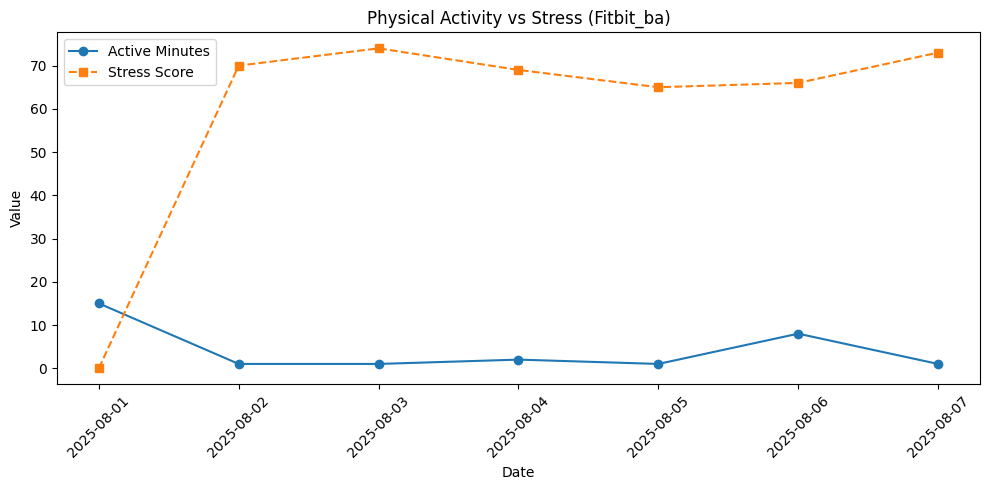

In [40]:
plt.figure(figsize=(10, 5))

plt.plot(
    activity_stress["date"],
    activity_stress["active_minutes"],
    marker="o",
    label="Active Minutes"
)

plt.plot(
    activity_stress["date"],
    activity_stress["stress_score"],
    marker="s",
    linestyle="--",
    label="Stress Score"
)

plt.title("Physical Activity vs Stress (Fitbit_ba)")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [41]:
activity_stress[["active_minutes", "stress_score"]].corr()


,active_minutes,stress_score
active_minutes,1.000000,-0.903909
stress_score,-0.903909,1.000000
